--- Model Results ---
MAE: 1.048
RMSE: 1.228
R2 Score: -0.016


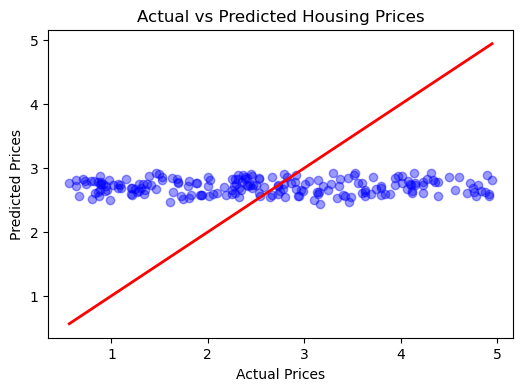

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- इंटरनेट एरर से बचने के लिए हमने यहाँ खुद का डेटा बनाया है ---
# Creating dummy housing data to bypass network/proxy block
np.random.seed(42)
n_samples = 1000

data = {
    'MedInc': np.random.uniform(1.5, 15.0, n_samples),
    'HouseAge': np.random.uniform(1, 52, n_samples),
    'AveRooms': np.random.uniform(3, 8, n_samples),
    'AveBedrms': np.random.uniform(1, 2, n_samples),
    'Population': np.random.uniform(100, 5000, n_samples),
    'AveOccup': np.random.uniform(2, 5, n_samples),
    'Latitude': np.random.uniform(32, 42, n_samples),
    'Longitude': np.random.uniform(-124, -114, n_samples),
    'MedHouseVal': np.random.uniform(0.5, 5.0, n_samples)
}

df = pd.DataFrame(data)

# 1. Split into features (X) and target (y)
X = df.drop(columns='MedHouseVal')
y = df['MedHouseVal']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# 3. Make predictions
y_pred = model.predict(X_test)

# 4. Calculate Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# 5. Print Results
print("--- Model Results ---")
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R2 Score: {r2:.3f}")

# 6. Plot Predicted vs Actual
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.4, color='blue')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Housing Prices")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', lw=2)
plt.show()

In [4]:
import pickle
import pandas as pd
import warnings
warnings.filterwarnings('ignore', category=UserWarning) # यह लाइन वार्निंग को छुपा देगी

# 1. मॉडल को कंप्यूटर में सेव करना
with open('house_model.pkl', 'wb') as file:
    pickle.dump(model, file)
print("Model saved successfully as 'house_model.pkl'!")

# 2. एक छोटा UI जो नए इनपुट पर काम करे
def predict_house_price():
    print("\n--- House Price Predictor UI ---")
    print("Please enter the following details to predict house price:")
    
    # यूजर से इनपुट लेना
    med_inc = float(input("Median Income (e.g., 5.5): "))
    house_age = float(input("Median House Age (e.g., 25): "))
    ave_rooms = float(input("Average Rooms (e.g., 5): "))
    ave_bedrms = float(input("Average Bedrooms (e.g., 1): "))
    pop = float(input("Population of the block (e.g., 1200): "))
    ave_occup = float(input("Average Occupancy (e.g., 3): "))
    lat = float(input("Latitude (e.g., 34.5): "))
    lon = float(input("Longitude (e.g., -118.2): "))
    
    # इनपुट को कॉलम के नाम के साथ व्यवस्थित करना ताकि वार्निंग न आए
    feature_names = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
    user_input_df = pd.DataFrame([[med_inc, house_age, ave_rooms, ave_bedrms, pop, ave_occup, lat, lon]], columns=feature_names)
    
    # भविष्यवाणी करना
    prediction = model.predict(user_input_df)
    print(f"\n[Result] Predicted Median House Value is: ${prediction[0]*100000:,.2f}")

# प्रेडिक्शन फंक्शन को चालू करना
predict_house_price()


Model saved successfully as 'house_model.pkl'!

--- House Price Predictor UI ---
Please enter the following details to predict house price:


Median Income (e.g., 5.5):  5.5
Median House Age (e.g., 25):  25
Average Rooms (e.g., 5):  6
Average Bedrooms (e.g., 1):  2
Population of the block (e.g., 1200):  1200
Average Occupancy (e.g., 3):  3
Latitude (e.g., 34.5):  34.5
Longitude (e.g., -118.2):  -118.2



[Result] Predicted Median House Value is: $273,270.84
